In [1]:
from google.colab import files
uploaded=files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition (2).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [3]:
df=pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_copy=df.copy()

In [4]:
df.shape

(1470, 35)

In [5]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [6]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
df.drop('EmployeeCount', axis=1, inplace=True)
df.drop('StockOptionLevel', axis=1, inplace=True)
df.drop('StandardHours', axis=1, inplace=True)
df.drop('DailyRate', axis=1, inplace=True)
df.drop('EmployeeNumber', axis=1, inplace=True)
df.drop('HourlyRate', axis=1, inplace=True)
df.drop('MonthlyRate', axis=1, inplace=True)
df.drop('Over18', axis=1, inplace=True)
df.drop('TrainingTimesLastYear', axis=1, inplace=True)

In [9]:
leaved=round((df['Attrition']=='Yes').sum()/df['Attrition'].count()*100,2)
print(f"Employes leaved till now {leaved}%")
not_leaved=round((df['Attrition']=='No').sum()/df['Attrition'].count()*100,2)
print(f"Employes that are currently working {not_leaved}%")

Employes leaved till now 16.12%
Employes that are currently working 83.88%


In [10]:
df.isnull().sum().sum()

np.int64(0)

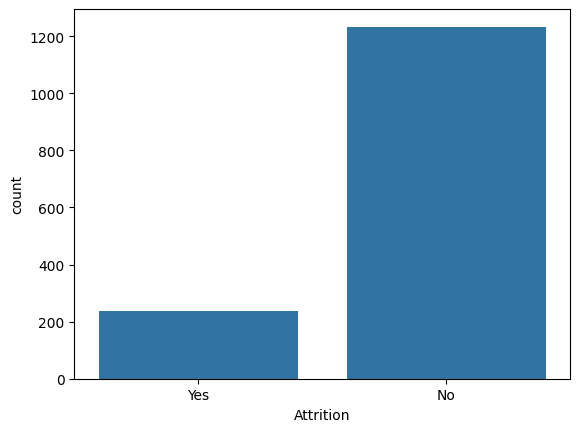

In [11]:
sns.countplot(data=df,x='Attrition')
plt.show()

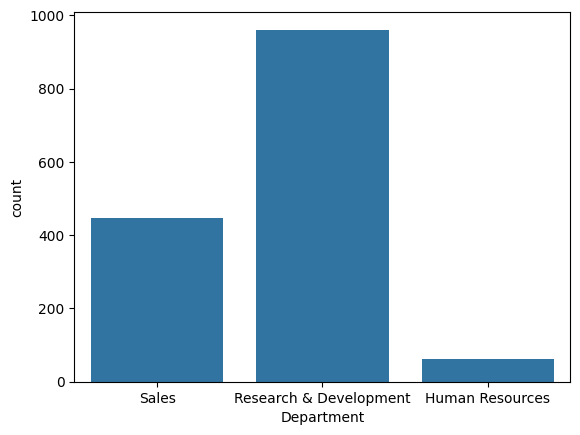

In [12]:
sns.countplot(data=df,x='Department')
plt.show()

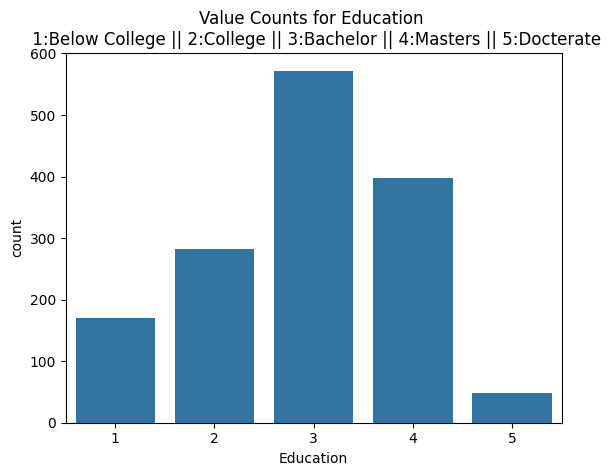

In [13]:
sns.countplot(data=df,x='Education')
plt.title('Value Counts for Education \n 1:Below College || 2:College || 3:Bachelor || 4:Masters || 5:Docterate')
plt.show()

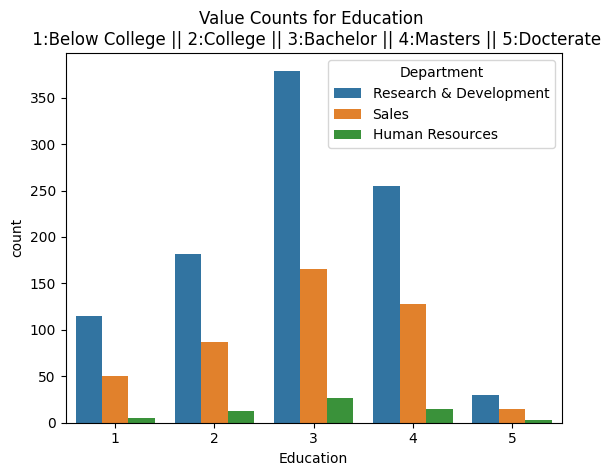

In [14]:
sns.countplot(data=df,x='Education',hue='Department')
plt.title('Value Counts for Education \n 1:Below College || 2:College || 3:Bachelor || 4:Masters || 5:Docterate')
plt.show()

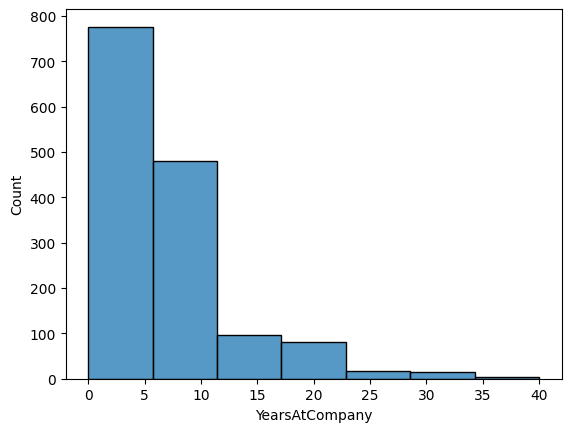

In [15]:
sns.histplot(data=df,x='YearsAtCompany',bins=7)
plt.show()

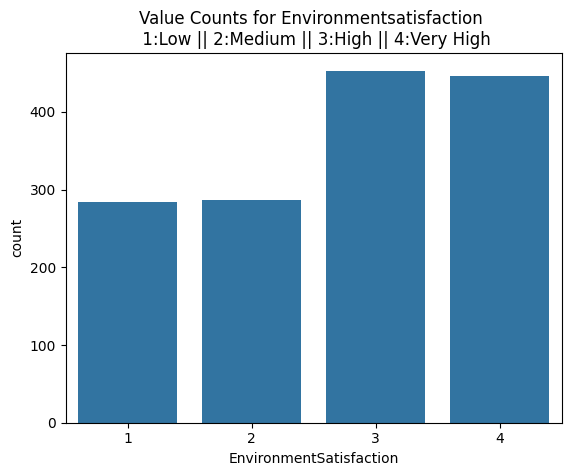

In [16]:
sns.countplot(data=df,x='EnvironmentSatisfaction')
plt.title('Value Counts for Environmentsatisfaction \n 1:Low || 2:Medium || 3:High || 4:Very High')
plt.show()

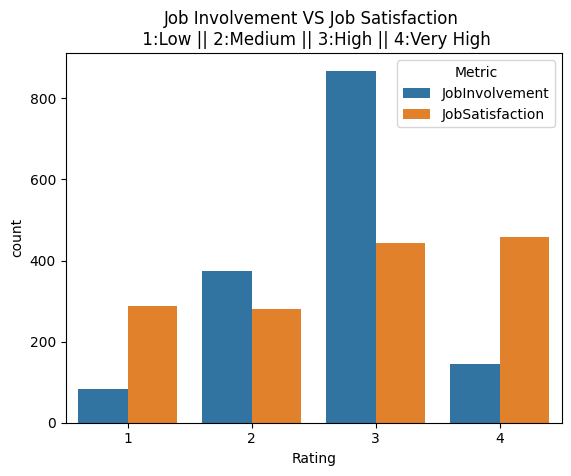

In [17]:
melted = df.melt(value_vars=['JobInvolvement', 'JobSatisfaction'], var_name='Metric',value_name='Rating')

sns.countplot(data=melted, x='Rating', hue='Metric')
plt.title('Job Involvement VS Job Satisfaction \n 1:Low || 2:Medium || 3:High || 4:Very High')
plt.show()


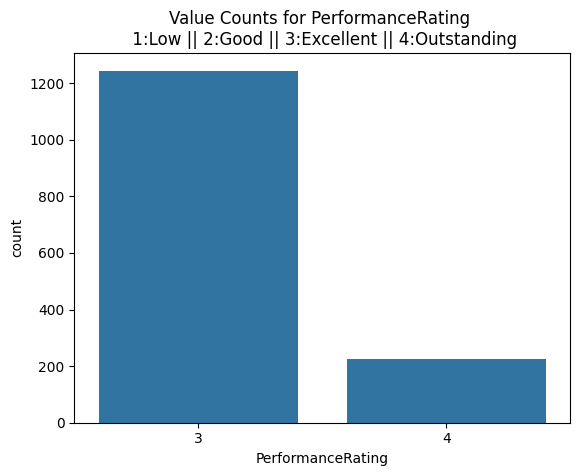

In [18]:
sns.countplot(data=df,x='PerformanceRating')
plt.title('Value Counts for PerformanceRating \n 1:Low || 2:Good || 3:Excellent || 4:Outstanding')
plt.show()

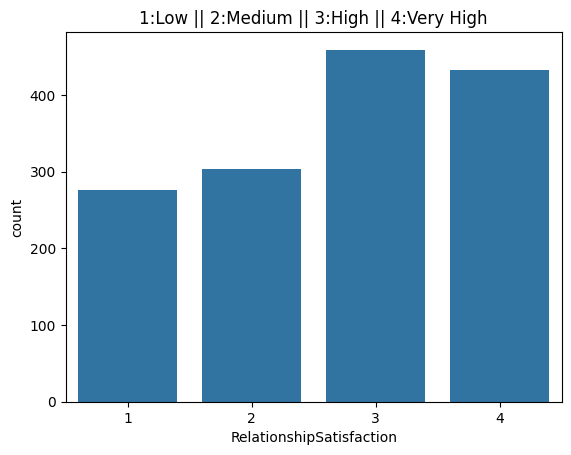

In [19]:
sns.countplot(data=df,x='RelationshipSatisfaction')
plt.title('1:Low || 2:Medium || 3:High || 4:Very High')
plt.show()

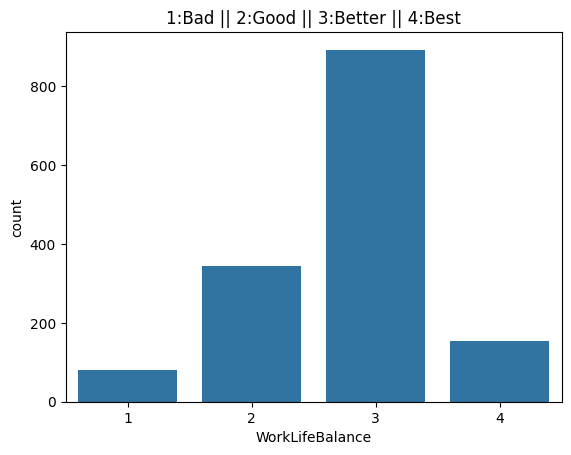

In [20]:
sns.countplot(data=df,x='WorkLifeBalance')
plt.title('1:Bad || 2:Good || 3:Better || 4:Best')
plt.show()

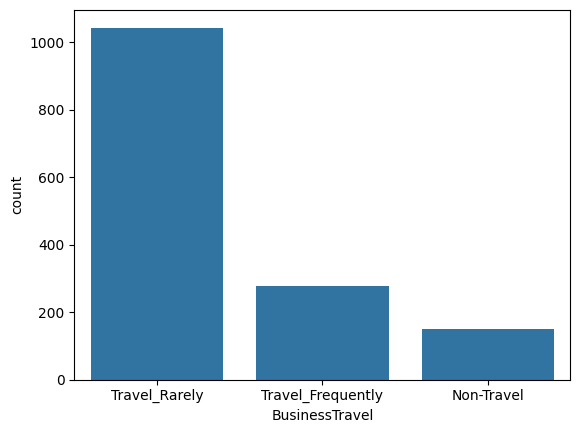

In [21]:
sns.countplot(data=df,x='BusinessTravel')
plt.show()

In [22]:
df['Attrition'] = df['Attrition'].map({'Yes':1,'No':0})
df['OverTime'] = df['OverTime'].map({'Yes':1,'No':0})
df['Gender'] = df['Gender'].map({'Male':1,'Female':0})

In [23]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [24]:
cat_features=x.select_dtypes(include='object').columns
num_features=x.select_dtypes(include=['int64','float64']).columns

In [25]:
cat_transformer=Pipeline([
    ('cat_impute',SimpleImputer(strategy='most_frequent')),
    ('cat_encoder',OneHotEncoder(handle_unknown='ignore'))
])

num_transformer=Pipeline([
    ('num_impute',SimpleImputer(strategy='mean')),
    ('num_encoder',StandardScaler())
])

transform=ColumnTransformer([
    ('cat_transformation',cat_transformer,cat_features),
    ('num_transformation',num_transformer,num_features)
])


In [26]:
skf=StratifiedKFold(n_splits=3,shuffle=True,random_state=13)

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from sklearn.metrics import roc_curve,f1_score,recall_score,classification_report,accuracy_score,roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split

In [28]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.30,train_size=0.70,random_state=13)

In [29]:
log_pipeline=Pipeline([
    ('transformer',transform),
    ('smote',SMOTE(random_state=13)),
    ('model',LogisticRegression(class_weight='balanced'))
])

log_cv=cross_validate(log_pipeline,x,y,cv=skf,error_score='raise',scoring=['roc_auc'])

param_grid = [
    {"model__C":[0.01, 0.1, 1,10]},
    {"model__max_iter":[100,200,250]}

]

rsv=RandomizedSearchCV(estimator=log_pipeline,param_distributions=param_grid,n_jobs=-1,random_state=13,cv=skf, scoring='accuracy')

rsv.fit(x_train,y_train)
y_pred=rsv.predict(x_test)

print("Best CV Score:", rsv.best_score_)
print("ROC_AUC Score:", roc_auc_score(y_test, y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 7 is smaller than n_iter=10. Running 7 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best CV Score: 0.7881438289601554
ROC_AUC Score: 0.7314016172506738


In [30]:
xgb_pipeline = Pipeline([
    ('transform',transform),
    ('smote', SMOTE()),
    ('model', XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,random_state=42,eval_metric='logloss'))
])

xgb_cv=cross_validate(xgb_pipeline,x,y,cv=skf,error_score='raise',scoring=['roc_auc'])

param_grid={
      "model": [XGBClassifier(random_state=42,eval_metric='logloss')],
      "model__n_estimators": [100, 200],
      "model__learning_rate": [0.01, 0.05, 0.1],
      "model__max_depth": [3, 5],
      "model__subsample": [0.8, 1.0]
}

rsv=RandomizedSearchCV(estimator=xgb_pipeline,param_distributions=param_grid,n_jobs=-1,random_state=13,cv=skf, scoring='accuracy')

rsv.fit(x_train,y_train)
y_pred=rsv.predict(x_test)

print("Best CV Score:", rsv.best_score_)
print("ROC_AUC Score:", roc_auc_score(y_test, y_pred))

Best CV Score: 0.8649173955296404
ROC_AUC Score: 0.6677897574123989


In [31]:
boost_pipeline = Pipeline([
    ('transform',transform),
    ('smote', SMOTE()),
    ('model', GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,random_state=42))

])

grad_boost_cv = cross_validate(boost_pipeline,x,y,cv=skf,scoring=['roc_auc'])

param_grid={
    "model": [GradientBoostingClassifier()],
      "model__n_estimators": [100, 200],
      "model__learning_rate": [0.05, 0.1],
      "model__max_depth": [3, 4]
}

rsv.fit(x_train,y_train)
y_pred=rsv.predict(x_test)

print("Best CV Score:", rsv.best_score_)
print("ROC_AUC Score:", roc_auc_score(y_test, y_pred))

Best CV Score: 0.8678328474246841
ROC_AUC Score: 0.6508086253369272


In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

x_train_transformed = transform.fit_transform(x_train)
x_test_transformed = transform.transform(x_test)

input_dim = x_train_transformed.shape[1]

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.3),

    layers.Dense(32, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [33]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))

In [35]:
history = model.fit(
    x_train_transformed, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 263ms/step - auc: 0.5735 - loss: 0.7818 - precision: 0.2682 - recall: 0.3112 - val_auc: 0.5109 - val_loss: 0.6310 - val_precision: 0.1176 - val_recall: 0.2759
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - auc: 0.5759 - loss: 0.7281 - precision: 0.2197 - recall: 0.4096 - val_auc: 0.5410 - val_loss: 0.6657 - val_precision: 0.1429 - val_recall: 0.4483
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - auc: 0.5988 - loss: 0.6871 - precision: 0.2098 - recall: 0.5249 - val_auc: 0.5984 - val_loss: 0.6765 - val_precision: 0.1667 - val_recall: 0.5862
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - auc: 0.6527 - loss: 0.6744 - precision: 0.2436 - recall: 0.5671 - val_auc: 0.6471 - val_loss: 0.6882 - val_precision: 0.1786 - val_recall: 0.6897
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - auc: 0.6434 - loss: 0.6767 - precision: 0.2300 - recall: 0.5692 - val_auc: 0.6856 - val_loss: 0.6996 - val_precision: 0.1901 - val_recall: 0.7931
Epoch 6/30
4/4

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred_prob = model.predict(x_test_transformed)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_prob))

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

           0       0.88      0.97      0.93       371
           1       0.70      0.33      0.45        70

    accuracy                           0.87       441
   macro avg       0.79      0.65      0.69       441
weighted avg       0.85      0.87      0.85       441

ROC-AUC: 0.8328455910666153


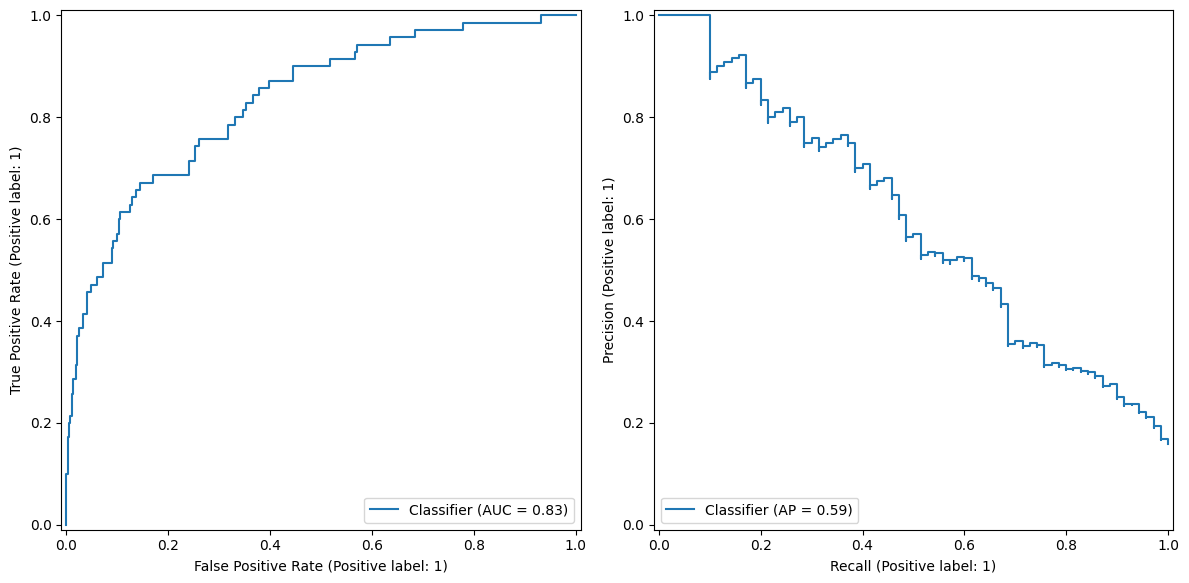

In [37]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, ax = plt.subplots(1, 2, figsize=(12, 12))

RocCurveDisplay.from_predictions(y_test, y_pred_prob,ax=ax[0])

PrecisionRecallDisplay.from_predictions(y_test, y_pred_prob,ax=ax[1])

plt.tight_layout()
plt.show()